In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

In [2]:
# Cambiamos las opciones de visualizacion de los dataframe a un formato mas amigable
pd.options.display.max_columns = None
pd.options.display.float_format = "{:,.2f}".format

In [3]:
# Cargamos nuestros datos
df = pd.read_csv("cybersecurity_attacks.csv")
df.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,IoC Detected,28.67,NaN,Malware,Known Pattern B,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,IoC Detected,51.50,NaN,Malware,Known Pattern A,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,IoC Detected,87.42,Alert Triggered,DDoS,Known Pattern B,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,NaN,15.79,Alert Triggered,Malware,Known Pattern B,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,NaN,0.52,Alert Triggered,DDoS,Known Pattern B,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


In [4]:
# Scamos unas estadisticas base para analizar nuestros datos
df.describe(include="all").fillna("-")

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
count,40000,40000,40000,"40,000.00","40,000.00",40000,"40,000.00",40000,40000,40000,20000,"40,000.00",19933,40000,40000,40000,40000,40000,40000,40000,40000,20149,20039,19950,40000
unique,39997,40000,40000,-,-,3,-,2,3,40000,1,-,1,3,2,3,3,32389,32104,3,8723,20148,1,1,2
top,2022-06-11 14:28:15,103.216.15.12,84.9.164.252,-,-,ICMP,-,Control,DNS,Qui natus odio asperiores nam. Optio nobis ius...,IoC Detected,-,Alert Triggered,DDoS,Known Pattern A,Blocked,Medium,Ishaan Chaudhari,Mozilla/5.0 (compatible; MSIE 6.0; Windows NT ...,Segment C,"Ghaziabad, Meghalaya",39.123.165.122,Log Data,Alert Data,Firewall
freq,2,1,1,-,-,13429,-,20237,13376,1,20000,-,19933,13428,20076,13529,13435,6,35,13408,16,2,20039,19950,20116
mean,-,-,-,"32,970.36","33,150.87",-,781.45,-,-,-,-,50.11,-,-,-,-,-,-,-,-,-,-,-,-,-
std,-,-,-,"18,560.43","18,574.67",-,416.04,-,-,-,-,28.85,-,-,-,-,-,-,-,-,-,-,-,-,-
min,-,-,-,"1,027.00","1,024.00",-,64.00,-,-,-,-,0.00,-,-,-,-,-,-,-,-,-,-,-,-,-
25%,-,-,-,"16,850.75","17,094.75",-,420.00,-,-,-,-,25.15,-,-,-,-,-,-,-,-,-,-,-,-,-
50%,-,-,-,"32,856.00","33,004.50",-,782.00,-,-,-,-,50.34,-,-,-,-,-,-,-,-,-,-,-,-,-
75%,-,-,-,"48,928.25","49,287.00",-,"1,143.00",-,-,-,-,75.03,-,-,-,-,-,-,-,-,-,-,-,-,-


In [5]:
# A priori parece que no hay datos nulos excepto en algunas columnas
df.isna().mean()

Timestamp                0.00
Source IP Address        0.00
Destination IP Address   0.00
Source Port              0.00
Destination Port         0.00
Protocol                 0.00
Packet Length            0.00
Packet Type              0.00
Traffic Type             0.00
Payload Data             0.00
Malware Indicators       0.50
Anomaly Scores           0.00
Alerts/Warnings          0.50
Attack Type              0.00
Attack Signature         0.00
Action Taken             0.00
Severity Level           0.00
User Information         0.00
Device Information       0.00
Network Segment          0.00
Geo-location Data        0.00
Proxy Information        0.50
Firewall Logs            0.50
IDS/IPS Alerts           0.50
Log Source               0.00
dtype: float64

In [6]:
# Si convertimos datos de manera rapida, parece que tenemos muchos datos categoricos
df.convert_dtypes().dtypes

Timestamp                 string[python]
Source IP Address         string[python]
Destination IP Address    string[python]
Source Port                        Int64
Destination Port                   Int64
Protocol                  string[python]
Packet Length                      Int64
Packet Type               string[python]
Traffic Type              string[python]
Payload Data              string[python]
Malware Indicators        string[python]
Anomaly Scores                   Float64
Alerts/Warnings           string[python]
Attack Type               string[python]
Attack Signature          string[python]
Action Taken              string[python]
Severity Level            string[python]
User Information          string[python]
Device Information        string[python]
Network Segment           string[python]
Geo-location Data         string[python]
Proxy Information         string[python]
Firewall Logs             string[python]
IDS/IPS Alerts            string[python]
Log Source      

In [7]:
cols_with_nan = ["Malware Indicators", "Alerts/Warnings", "Proxy Information", "Firewall Logs", "IDS/IPS Alerts"]
df[cols_with_nan]

,Malware Indicators,Alerts/Warnings,Proxy Information,Firewall Logs,IDS/IPS Alerts
0,IoC Detected,NaN,150.9.97.135,Log Data,NaN
1,IoC Detected,NaN,NaN,Log Data,NaN
2,IoC Detected,Alert Triggered,114.133.48.179,Log Data,Alert Data
3,NaN,Alert Triggered,NaN,NaN,Alert Data
4,NaN,Alert Triggered,149.6.110.119,NaN,Alert Data
...,...,...,...,...,...
39995,IoC Detected,NaN,NaN,Log Data,Alert Data
39996,IoC Detected,NaN,60.51.30.46,Log Data,NaN
39997,IoC Detected,NaN,NaN,Log Data,Alert Data
39998,IoC Detected,Alert Triggered,137.76.130.8,Log Data,NaN


In [8]:
# A priori no hay correlacion lineal alguna entre las columnas con nan
df[cols_with_nan].isna().corr()

,Malware Indicators,Alerts/Warnings,Proxy Information,Firewall Logs,IDS/IPS Alerts
Malware Indicators,1.00,-0.00,0.00,0.00,0.01
Alerts/Warnings,-0.00,1.00,-0.00,-0.00,-0.00
Proxy Information,0.00,-0.00,1.00,-0.00,-0.00
Firewall Logs,0.00,-0.00,-0.00,1.00,0.01
IDS/IPS Alerts,0.01,-0.00,-0.00,0.01,1.00


In [9]:
# Como son variables categorias, el que hecho que haya nulos puede considerarse como otra clase mas
df[cols_with_nan] = df[cols_with_nan].fillna("NULL")

In [10]:
df.describe(include="all").fillna("-")

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
count,40000,40000,40000,"40,000.00","40,000.00",40000,"40,000.00",40000,40000,40000,40000,"40,000.00",40000,40000,40000,40000,40000,40000,40000,40000,40000,40000,40000,40000,40000
unique,39997,40000,40000,-,-,3,-,2,3,40000,2,-,2,3,2,3,3,32389,32104,3,8723,20149,2,2,2
top,2022-06-11 14:28:15,103.216.15.12,84.9.164.252,-,-,ICMP,-,Control,DNS,Qui natus odio asperiores nam. Optio nobis ius...,IoC Detected,-,NULL,DDoS,Known Pattern A,Blocked,Medium,Ishaan Chaudhari,Mozilla/5.0 (compatible; MSIE 6.0; Windows NT ...,Segment C,"Ghaziabad, Meghalaya",NULL,Log Data,NULL,Firewall
freq,2,1,1,-,-,13429,-,20237,13376,1,20000,-,20067,13428,20076,13529,13435,6,35,13408,16,19851,20039,20050,20116
mean,-,-,-,"32,970.36","33,150.87",-,781.45,-,-,-,-,50.11,-,-,-,-,-,-,-,-,-,-,-,-,-
std,-,-,-,"18,560.43","18,574.67",-,416.04,-,-,-,-,28.85,-,-,-,-,-,-,-,-,-,-,-,-,-
min,-,-,-,"1,027.00","1,024.00",-,64.00,-,-,-,-,0.00,-,-,-,-,-,-,-,-,-,-,-,-,-
25%,-,-,-,"16,850.75","17,094.75",-,420.00,-,-,-,-,25.15,-,-,-,-,-,-,-,-,-,-,-,-,-
50%,-,-,-,"32,856.00","33,004.50",-,782.00,-,-,-,-,50.34,-,-,-,-,-,-,-,-,-,-,-,-,-
75%,-,-,-,"48,928.25","49,287.00",-,"1,143.00",-,-,-,-,75.03,-,-,-,-,-,-,-,-,-,-,-,-,-


In [11]:
# Nuestras variables objetivo estan balanceadas
df["Action Taken"].value_counts()

Action Taken
Blocked    13529
Ignored    13276
Logged     13195
Name: count, dtype: int64

In [12]:
df["Severity Level"].value_counts()

Severity Level
Medium    13435
High      13382
Low       13183
Name: count, dtype: int64

In [13]:
df["Attack Type"].value_counts()

Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64

In [14]:
# No hay correlacion lineal entre las variables objetivo
cols_to_predict = ["Action Taken", "Severity Level", "Attack Type"]
df[cols_to_predict].astype("category").apply(lambda x: x.cat.codes).corr()

,Action Taken,Severity Level,Attack Type
Action Taken,1.00,0.00,0.00
Severity Level,0.00,1.00,0.01
Attack Type,0.00,0.01,1.00


In [15]:
# (avanzado) Como la correlacion por defecto (pearson) solo sirve para correlacion lineal de variables numericas, no la podemos usar para variables categoricas
# Para las categoricas vamos a usar chi cuadrado

from scipy.stats import chi2_contingency

def categorical_correlation_analysis(df, cols_to_predict):
    n = len(cols_to_predict)
    cramers_v_matrix = pd.DataFrame(np.zeros((n, n)), columns=cols_to_predict, index=cols_to_predict)
    pvalue_matrix = pd.DataFrame(np.zeros((n, n)), columns=cols_to_predict, index=cols_to_predict)

    for i, col1 in enumerate(cols_to_predict):
        for j, col2 in enumerate(cols_to_predict):
            if i != j:  # Skip diagonal (same column)
                contingency_table = pd.crosstab(df[col1], df[col2])
                chi2, p, dof, expected = chi2_contingency(contingency_table)
                
                # Calculate Cramer's V
                n = contingency_table.sum().sum()
                min_dim = min(contingency_table.shape) - 1
                cramers_v = np.sqrt(chi2 / (n * min_dim))
                
                cramers_v_matrix.iloc[i, j] = cramers_v
                pvalue_matrix.iloc[i, j] = p

    # Fill diagonal with 1 for Cramer's V and 0 for p-value
    np.fill_diagonal(cramers_v_matrix.values, 1)
    np.fill_diagonal(pvalue_matrix.values, 0)

    return cramers_v_matrix, pvalue_matrix

cramers_v_df, pvalue_df = categorical_correlation_analysis(df, cols_to_predict)
cramers_v_df

,Action Taken,Severity Level,Attack Type
Action Taken,1.00,0.01,0.01
Severity Level,0.01,1.00,0.00
Attack Type,0.01,0.00,1.00


### Interpreting Cramer's V:

- 0.00 to 0.10: Negligible association
- 0.10 to 0.30: Weak association
- 0.30 to 0.50: Moderate association
- 0.50 to 0.70: Strong association
- 0.70 to 1.00: Very strong association

In [16]:
# al usar esta correlacion, si encontramos ciertas relaciones entre las categorias
cramers_v_df, pvalue_df = categorical_correlation_analysis(df, cols_with_nan)
cramers_v_df

,Malware Indicators,Alerts/Warnings,Proxy Information,Firewall Logs,IDS/IPS Alerts
Malware Indicators,1.00,0.00,0.71,0.00,0.01
Alerts/Warnings,0.00,1.00,0.71,0.00,0.00
Proxy Information,0.71,0.71,1.00,0.71,0.71
Firewall Logs,0.00,0.00,0.71,1.00,0.01
IDS/IPS Alerts,0.01,0.00,0.71,0.01,1.00


In [17]:
cramers_v_df, pvalue_df = categorical_correlation_analysis(df, cols_to_predict + cols_with_nan)
cramers_v_df

,Action Taken,Severity Level,Attack Type,Malware Indicators,Alerts/Warnings,Proxy Information,Firewall Logs,IDS/IPS Alerts
Action Taken,1.00,0.01,0.01,0.01,0.00,0.71,0.00,0.00
Severity Level,0.01,1.00,0.00,0.00,0.00,0.71,0.00,0.01
Attack Type,0.01,0.00,1.00,0.01,0.01,0.71,0.00,0.00
Malware Indicators,0.01,0.00,0.01,1.00,0.00,0.71,0.00,0.01
Alerts/Warnings,0.00,0.00,0.01,0.00,1.00,0.71,0.00,0.00
Proxy Information,0.71,0.71,0.71,0.71,0.71,1.00,0.71,0.71
Firewall Logs,0.00,0.00,0.00,0.00,0.00,0.71,1.00,0.01
IDS/IPS Alerts,0.00,0.01,0.00,0.01,0.00,0.71,0.01,1.00


In [18]:
df[cols_to_predict + cols_with_nan].describe(include="all")

,Action Taken,Severity Level,Attack Type,Malware Indicators,Alerts/Warnings,Proxy Information,Firewall Logs,IDS/IPS Alerts
count,40000,40000,40000,40000,40000,40000,40000,40000
unique,3,3,3,2,2,20149,2,2
top,Blocked,Medium,DDoS,IoC Detected,NULL,NULL,Log Data,NULL
freq,13529,13435,13428,20000,20067,19851,20039,20050


In [19]:
df["Proxy Information"] = df["Proxy Information"]!="NULL"

In [20]:
# y podemos extraer que esa correlacion es debida a la aparicion de los valores nulos. Como los hemos convertido en una categoria extra, lo podemos estudiar
# aqui mostramos las correlaciones si quitamos los valores nulos. Observamos que la correlacion desaparece
cramers_v_df, pvalue_df = categorical_correlation_analysis(df, cols_to_predict + cols_with_nan)
cramers_v_df

,Action Taken,Severity Level,Attack Type,Malware Indicators,Alerts/Warnings,Proxy Information,Firewall Logs,IDS/IPS Alerts
Action Taken,1.00,0.01,0.01,0.01,0.00,0.01,0.00,0.00
Severity Level,0.01,1.00,0.00,0.00,0.00,0.01,0.00,0.01
Attack Type,0.01,0.00,1.00,0.01,0.01,0.01,0.00,0.00
Malware Indicators,0.01,0.00,0.01,1.00,0.00,0.00,0.00,0.01
Alerts/Warnings,0.00,0.00,0.01,0.00,1.00,0.00,0.00,0.00
Proxy Information,0.01,0.01,0.01,0.00,0.00,1.00,0.00,0.00
Firewall Logs,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.01
IDS/IPS Alerts,0.00,0.01,0.00,0.01,0.00,0.00,0.01,1.00


In [21]:
numerical_cols = ['Packet Length', 'Anomaly Scores']

In [22]:
df[numerical_cols].describe()

,Packet Length,Anomaly Scores
count,"40,000.00","40,000.00"
mean,781.45,50.11
std,416.04,28.85
min,64.00,0.00
25%,420.00,25.15
50%,782.00,50.34
75%,"1,143.00",75.03
max,"1,500.00",100.00


<Axes: xlabel='Packet Length', ylabel='index'>

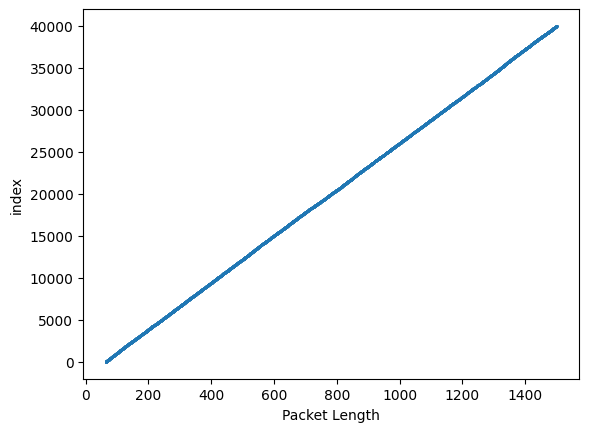

In [23]:
# para las variables numericas, no hay outliers
df["Packet Length"].sort_values().reset_index(drop=True).reset_index().plot.scatter(x="Packet Length", y="index", s=0.1)

<Axes: xlabel='Packet Length', ylabel='Anomaly Scores'>

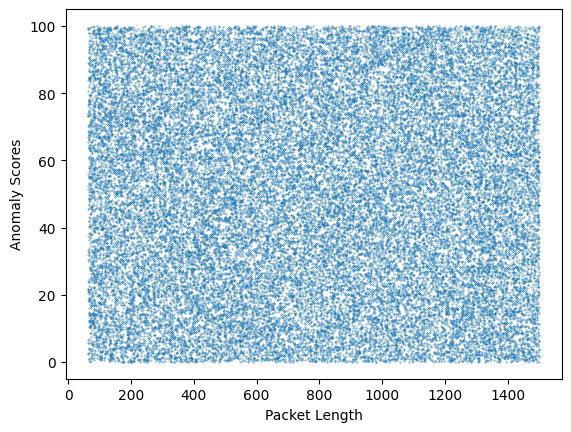

In [24]:
# y la distribucion parece ser completamente aleatoria
df[numerical_cols].plot.scatter(x="Packet Length", y="Anomaly Scores", s=0.1)

In [25]:
# convertimos todos los valores nulos a categoricos, como hemos visto antes
categorical_columns = [c for c in df.columns if c not in numerical_cols]
for c in categorical_columns:
    df[c] = df[c].fillna("NULL").astype("category")

In [26]:
df.describe(include="all").fillna("-")

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
count,40000,40000,40000,"40,000.00","40,000.00",40000,"40,000.00",40000,40000,40000,40000,"40,000.00",40000,40000,40000,40000,40000,40000,40000,40000,40000,40000,40000,40000,40000
unique,39997,40000,40000,"29,761.00","29,895.00",3,-,2,3,40000,2,-,2,3,2,3,3,32389,32104,3,8723,2,2,2,2
top,2022-04-17 20:05:34,1.1.45.194,1.1.189.171,"41,341.00","34,117.00",ICMP,-,Control,DNS,A ab tempora a. Culpa et fuga maxime. Quia ad ...,IoC Detected,-,NULL,DDoS,Known Pattern A,Blocked,Medium,Heer Lad,Mozilla/5.0 (compatible; MSIE 6.0; Windows NT ...,Segment C,"Ghaziabad, Meghalaya",True,Log Data,NULL,Firewall
freq,2,1,1,6.00,6.00,13429,-,20237,13376,1,20000,-,20067,13428,20076,13529,13435,6,35,13408,16,20149,20039,20050,20116
mean,-,-,-,-,-,-,781.45,-,-,-,-,50.11,-,-,-,-,-,-,-,-,-,-,-,-,-
std,-,-,-,-,-,-,416.04,-,-,-,-,28.85,-,-,-,-,-,-,-,-,-,-,-,-,-
min,-,-,-,-,-,-,64.00,-,-,-,-,0.00,-,-,-,-,-,-,-,-,-,-,-,-,-
25%,-,-,-,-,-,-,420.00,-,-,-,-,25.15,-,-,-,-,-,-,-,-,-,-,-,-,-
50%,-,-,-,-,-,-,782.00,-,-,-,-,50.34,-,-,-,-,-,-,-,-,-,-,-,-,-
75%,-,-,-,-,-,-,"1,143.00",-,-,-,-,75.03,-,-,-,-,-,-,-,-,-,-,-,-,-


## Preprocesamiento

In [27]:
# Timestamp puede ser util, pero no hemos aprendido a tratar con series temporales, el resto tienen cardinalidad=N, con lo que no aporta info
# Payload data podria ser util, pero no hemos aprendido a sacar features de texto natural (es mas deep learning) y ademas el dato es Lorem Ipsum, con lo que a priori no parece que tenga información.
# las eliminamos
useless_cols = ["Timestamp", "Source IP Address", "Destination IP Address", "Payload Data"]
cols_to_predict = ["Action Taken", "Severity Level", "Attack Type"]
df = df.drop(columns=useless_cols)
df.head()

,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,31225,17616,ICMP,503,Data,HTTP,IoC Detected,28.67,NULL,Malware,Known Pattern B,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",True,Log Data,NULL,Server
1,17245,48166,ICMP,1174,Data,HTTP,IoC Detected,51.50,NULL,Malware,Known Pattern A,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",False,Log Data,NULL,Firewall
2,16811,53600,UDP,306,Control,HTTP,IoC Detected,87.42,Alert Triggered,DDoS,Known Pattern B,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",True,Log Data,Alert Data,Firewall
3,20018,32534,UDP,385,Data,HTTP,NULL,15.79,Alert Triggered,Malware,Known Pattern B,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",False,NULL,Alert Data,Firewall
4,6131,26646,TCP,1462,Data,DNS,NULL,0.52,Alert Triggered,DDoS,Known Pattern B,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",True,NULL,Alert Data,Firewall


/var/folders/m8/xdt0_33s3vj1_8q5nl0qf05w0000gn/T/ipykernel_2855/1464529007.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[c] = X[c].cat.codes


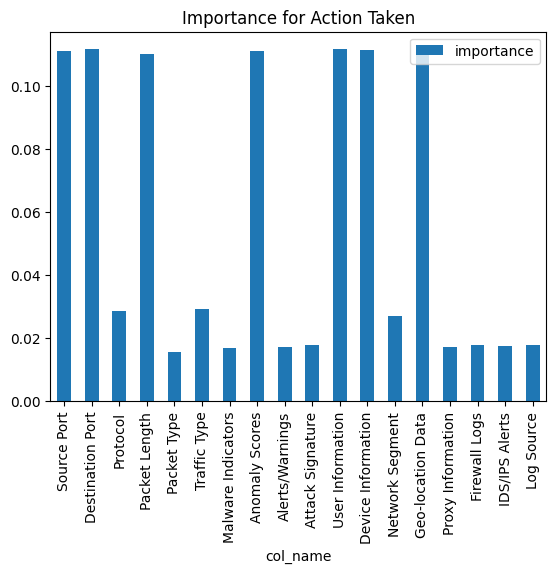

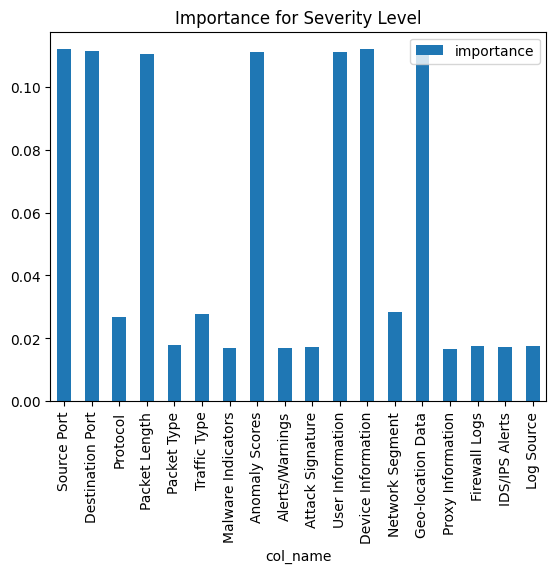

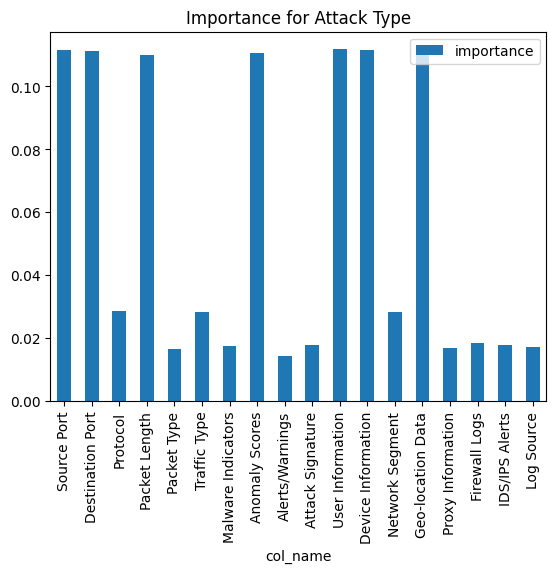

In [28]:
# entrenamos un random forest rapidamente para extraer la importancia de las variables
# parece que todas tienen cierta importancia, aunque la similitud de valores es sospechosa

from sklearn.ensemble import RandomForestClassifier

X_cols = [c for c in df.columns if c not in cols_to_predict]
X = df[X_cols]
for c in X.select_dtypes("category"):
    X[c] = X[c].cat.codes

for y_col in cols_to_predict:
    clf = RandomForestClassifier().fit(X, df[y_col].cat.codes)
    pd.DataFrame({"col_name": X_cols, "importance":clf.feature_importances_}).plot.bar(x="col_name", title=f"Importance for {y_col}")
    plt.plot()

<Axes: xlabel='Source Port', ylabel='index'>

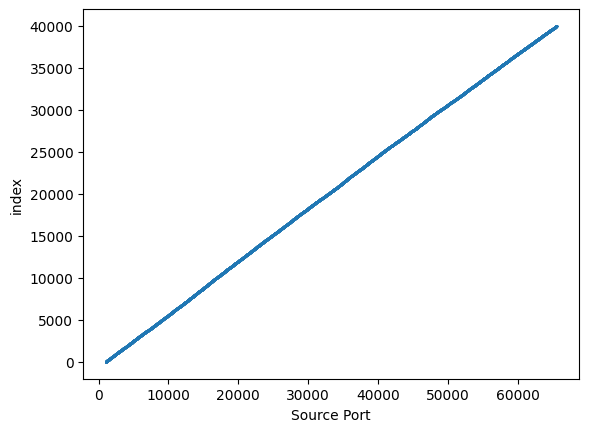

In [29]:
# source port tampoco tiene outliers
df["Source Port"].astype(int).sort_values().reset_index(drop=True).reset_index().plot.scatter(x="Source Port", y="index", s=0.1)

## 4 - Modelado

In [30]:
# entrenamos un random forest con su train/test split
# cualquier otro modelo categorico como logistic regression valdria
# usar una regresion lineal seria un grave error

# como los resultados son practicamente aleatorios, podemos obviar hacer un cross validation ya que no aportaria valor

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

for y_col in cols_to_predict:
    X_train, X_test, y_train, y_test = train_test_split(X, df[y_col].cat.codes, random_state=42)
    clf = RandomForestClassifier().fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"Classification report for {y_col}")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("-"*12)
    print()


Classification report for Action Taken
              precision    recall  f1-score   support

           0       0.33      0.39      0.36      3372
           1       0.32      0.32      0.32      3297
           2       0.34      0.28      0.31      3331

    accuracy                           0.33     10000
   macro avg       0.33      0.33      0.33     10000
weighted avg       0.33      0.33      0.33     10000

[[1323 1131  918]
 [1325 1061  911]
 [1311 1088  932]]
------------

Classification report for Severity Level
              precision    recall  f1-score   support

           0       0.33      0.39      0.36      3249
           1       0.35      0.32      0.33      3341
           2       0.34      0.31      0.33      3410

    accuracy                           0.34     10000
   macro avg       0.34      0.34      0.34     10000
weighted avg       0.34      0.34      0.34     10000

[[1263  969 1017]
 [1247 1066 1028]
 [1335 1005 1070]]
------------

Classification repor

## 5 - Conclusión

Tras el analisis todo parece indicar que no hay patrones aparentes en los datos. Tanto las graficas como los resultados de los modelos nos arrojan resultados de que las distribuciones son aleatorias. De ser asi seria normal que un modelo de ML diese los resultados que obtenemos. Asi que con toda la informacion recabada podemos estar bastante seguros de que no se pueden obtener mejores resultados.

# 6 - Extra

La presente practica es lo que algunas personas llaman una kata de ML. Es bastante comun en procesos de seleccion. Efectivamente no hay patrones en los datos ya que han sido generados de manera artificial.

Este tipo de ejercicos sirven para evaluar muy bien el conocimiento tecnico de una persona, ya que al no encontrar nada, lo normal es que una persona pruebe todas las tecnicas que conoce paso por paso y la conclusión final pone de manifiesto si la persona entiende realmente lo que hace. Aun asi, tampoco es raro encontrar datos reales que no tienen patrón alguno.

He querido hacer una practica asi principalmente por un motivo, si os volveis a encontrar una prueba similar en el futuro, en algun proceso de seleccion, que no sea la primera vez y podais ir con ventaja.